In [ ]:
from pathlib import Path
import numpy as np
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import timm

In [ ]:
candidates = [
    Path('train_data'),
    Path('../train_data'),
    Path.cwd() / 'train_data',
    Path.cwd().parent / 'train_data',
]
train_data_dir = next((p.resolve() for p in candidates if p.exists()), None)
if train_data_dir is None:
    raise FileNotFoundError(
        "Could not find 'train_data' folder. Tried: " + ", ".join(str(p) for p in candidates)
    )
print('Using train_data:', train_data_dir)

seed = 42
TRAIN_FRAC = 0.90  # train uses only 90% of images

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=str(train_data_dir), transform=transform)
num_classes = len(dataset.classes)
print('Num classes:', num_classes)

# Deterministic 90/10 split (disjoint)
n_all = len(dataset)
k_train = int(round(TRAIN_FRAC * n_all))
k_train = max(1, min(k_train, n_all - 1))  # ensure at least 1 train and 1 test

g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_all, generator=g)
train_idx = perm[:k_train].tolist()
test_idx = perm[k_train:].tolist()

train_img = Subset(dataset, train_idx)
test_img = Subset(dataset, test_idx)

batch_size = 32
num_workers = 4

g_loader = torch.Generator().manual_seed(seed)
train_loader = DataLoader(
    train_img,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    generator=g_loader,
)
test_loader = DataLoader(
    test_img,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    generator=g_loader,
)

print('Total images:', n_all)
print(f"Train images: {len(train_img)} ({len(train_img)/n_all:.0%})")
print(f"Test images:  {len(test_img)} ({len(test_img)/n_all:.0%})")
print('Classes (folder order used for labels):')
for i, name in enumerate(dataset.classes):
    print(f'  {i}: {name}')


Using train_data: /content/train_data
Num classes: 30
Total images: 6993
Train images: 6294 (90%)
Test images:  699 (10%)
Classes (folder order used for labels):
  0: Airport
  1: BareLand
  2: BaseballField
  3: Beach
  4: Bridge
  5: Center
  6: Church
  7: Commercial
  8: DenseResidential
  9: Desert
  10: Farmland
  11: Forest
  12: Industrial
  13: Meadow
  14: MediumResidential
  15: Mountain
  16: Park
  17: Parking
  18: Playground
  19: Pond
  20: Port
  21: RailwayStation
  22: Resort
  23: River
  24: School
  25: SparseResidential
  26: Square
  27: Stadium
  28: StorageTanks
  29: Viaduct


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [20]:
# Fine-tuning strategy comparison for EfficientNet-B0 (fixed hyperparameters)
# Strategies:
#  1) Linear probe
#  2) Last block fine-tuning  (deepest EfficientNet block + conv_head/bn2)
#  3) Full fine-tuning of the entire backbone
#  4) Selective layer unfreezing (<= 20% of backbone parameters)
#
# EfficientNet-B0 backbone structure (timm, typical):
#   conv_stem, bn1
#   blocks.<i> (MBConv blocks)
#   conv_head, bn2
#   classifier (FC head)

from dataclasses import dataclass
import math
import re

seed = globals().get("seed", 42)


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(seed)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


# ---------------------------
# Fixed hyperparameters
# ---------------------------
EPOCHS = 8
LR = 1e-3
WEIGHT_DECAY = 1e-4
OPTIMIZER_NAME = "adamw"

GRAD_NORM_EVERY = 10  # log gradient norm stats every N batches


def _is_head_param(name: str) -> bool:
    """Returns True if the parameter belongs to the classifier head."""
    return name.startswith("classifier.")


def _param_group_from_name(name: str) -> str:
    """Map an EfficientNet-B0 parameter name to a logical group for grad-norm tracking."""
    if _is_head_param(name):
        return "head"
    if name.startswith("conv_stem.") or name.startswith("bn1."):
        return "stem"
    # conv_head + bn2 are backbone late layers
    if name.startswith("conv_head.") or name.startswith("bn2."):
        return "late"
    if name.startswith("blocks."):
        return "blocks"
    return "backbone"


def count_trainable_params(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))


def backbone_named_parameters(model: nn.Module):
    for n, p in model.named_parameters():
        if not _is_head_param(n):
            yield n, p


def head_named_parameters(model: nn.Module):
    for n, p in model.named_parameters():
        if _is_head_param(n):
            yield n, p


def freeze_backbone(model: nn.Module) -> None:
    for _, p in backbone_named_parameters(model):
        p.requires_grad = False


def unfreeze_backbone(model: nn.Module) -> None:
    for _, p in backbone_named_parameters(model):
        p.requires_grad = True


def unfreeze_head(model: nn.Module) -> None:
    for _, p in head_named_parameters(model):
        p.requires_grad = True


def _set_bn_eval_for_frozen_params(model: nn.Module) -> None:
    """Set BatchNorm layers to eval mode when all their params are frozen."""
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            bn_params = list(m.parameters(recurse=False))
            if bn_params and all(not p.requires_grad for p in bn_params):
                m.eval()


def build_efficientnet_b0(num_classes: int, seed_for_head_init: int = 42) -> nn.Module:
    """Load pretrained EfficientNet-B0 and replace the classifier head."""
    set_seed(seed_for_head_init)
    model = timm.create_model("efficientnet_b0", pretrained=True)

    # Deterministic classifier head init
    set_seed(seed_for_head_init)
    model.reset_classifier(num_classes)

    model.to(device)
    model.train()
    return model


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader) -> tuple[float, float]:
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())

    return loss_sum / max(1, total), correct / max(1, total)


def make_optimizer(model: nn.Module) -> torch.optim.Optimizer:
    params = [p for p in model.parameters() if p.requires_grad]
    if OPTIMIZER_NAME.lower() == "adamw":
        return torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    if OPTIMIZER_NAME.lower() == "sgd":
        return torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=WEIGHT_DECAY)
    raise ValueError(f"Unknown OPTIMIZER_NAME={OPTIMIZER_NAME}")


def _block_index(param_name: str) -> int | None:
    m = re.match(r"^blocks\.(\d+)\.", param_name)
    if not m:
        return None
    return int(m.group(1))


def _depth_score(param_name: str) -> tuple[int, int]:
    """Higher score = deeper = should be unfrozen first."""
    if param_name.startswith("conv_head.") or param_name.startswith("bn2."):
        return (10_000, 0)
    idx = _block_index(param_name)
    if idx is not None:
        return (idx, 0)
    if param_name.startswith("conv_stem.") or param_name.startswith("bn1."):
        return (-1, 0)
    return (-2, 0)


def selective_unfreeze_backbone_20pct(model: nn.Module, fraction: float = 0.20) -> dict:
    """Selectively unfreeze the deepest backbone parameters within a parameter budget."""
    freeze_backbone(model)
    unfreeze_head(model)

    backbone_params = [(n, p) for n, p in model.named_parameters() if not _is_head_param(n)]
    total_backbone = sum(p.numel() for _, p in backbone_params)
    cap = int(total_backbone * fraction)

    backbone_params_sorted = sorted(backbone_params, key=lambda np_: _depth_score(np_[0]), reverse=True)

    selected_numel = 0
    selected_names: list[str] = []

    for n, p in backbone_params_sorted:
        n_el = p.numel()
        if selected_numel + n_el <= cap:
            p.requires_grad = True
            selected_numel += n_el
            selected_names.append(n)

    by_region = {"stem": 0, "blocks": 0, "late": 0, "other": 0}
    for n in selected_names:
        g = _param_group_from_name(n)
        if g in by_region:
            by_region[g] += 1
        else:
            by_region["other"] += 1

    rationale = (
        "Selective 20% strategy: Unfreeze the deepest EfficientNet layers first "
        "(conv_head/bn2 then highest-index blocks). "
        "Deep layers capture the most task-specific semantics and typically benefit most from "
        "fine-tuning under a tight parameter budget; early stem layers tend to transfer well."
    )

    return {
        "cap_params": cap,
        "selected_backbone_params": selected_numel,
        "selected_backbone_fraction": selected_numel / max(1, total_backbone),
        "total_backbone_params": total_backbone,
        "selected_param_tensors": len(selected_names),
        "by_region_tensors": by_region,
        "rationale": rationale,
    }


def compute_trainable_backbone_stats(model: nn.Module) -> tuple[int, int, float]:
    bb_all = [(n, p) for n, p in backbone_named_parameters(model)]
    bb_trainable = [(n, p) for n, p in bb_all if p.requires_grad]
    total = sum(p.numel() for _, p in bb_all)
    trainable = sum(p.numel() for _, p in bb_trainable)
    return int(trainable), int(total), float(trainable / max(1, total))


def configure_strategy(model: nn.Module, strategy: str) -> None:
    strategy = strategy.lower().strip()

    if strategy == "linear_probe":
        freeze_backbone(model)
        unfreeze_head(model)
        return

    if strategy == "last_block":
        freeze_backbone(model)
        unfreeze_head(model)

        # Unfreeze conv_head/bn2 (late backbone)
        for n, p in model.named_parameters():
            if n.startswith("conv_head.") or n.startswith("bn2."):
                p.requires_grad = True

        # Unfreeze the deepest block index present
        max_block = -1
        for n, _ in model.named_parameters():
            idx = _block_index(n)
            if idx is not None:
                max_block = max(max_block, idx)

        for n, p in model.named_parameters():
            if n.startswith(f"blocks.{max_block}."):
                p.requires_grad = True
        return

    if strategy == "full_finetune":
        unfreeze_backbone(model)
        unfreeze_head(model)
        return

    if strategy == "selective_20pct":
        info = selective_unfreeze_backbone_20pct(model, fraction=0.20)
        print("\n[Selective 20% Layer Unfreezing — Rationale]")
        print(info["rationale"])
        print(f"  Budget cap  : {info['cap_params']:,} params")
        print(
            f"  Unfrozen BB : {info['selected_backbone_params']:,} params "
            f"({info['selected_backbone_fraction']*100:.2f}% of backbone)"
        )
        print(f"  By region   : {info['by_region_tensors']}")
        return

    raise ValueError(f"Unknown strategy: {strategy}")


def compute_group_grad_norms(model: nn.Module) -> dict[str, float]:
    sumsq: dict[str, float] = {
        "stem": 0.0,
        "blocks": 0.0,
        "late": 0.0,
        "backbone": 0.0,
        "head": 0.0,
    }
    for n, p in model.named_parameters():
        if p.grad is None or (not p.requires_grad):
            continue
        g = p.grad.detach()
        if g.is_sparse:
            g = g.to_dense()
        g = g.float()
        group = _param_group_from_name(n)
        if group not in sumsq:
            group = "backbone"
        sumsq[group] += float((g * g).sum().item())
    return {k: math.sqrt(v) for k, v in sumsq.items()}


def _summarize_grad_samples(samples_by_group: dict[str, list[float]]) -> dict[str, dict[str, float]]:
    out: dict[str, dict[str, float]] = {}
    for group, vals in samples_by_group.items():
        if not vals:
            out[group] = {"mean": 0.0, "std": 0.0, "max": 0.0, "n": 0}
            continue
        arr = np.asarray(vals, dtype=np.float64)
        out[group] = {
            "mean": float(arr.mean()),
            "std": float(arr.std(ddof=0)),
            "max": float(arr.max()),
            "n": int(arr.size),
        }
    return out


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    grad_every: int = GRAD_NORM_EVERY,
) -> tuple[float, float, dict[str, dict[str, float]]]:
    model.train()
    _set_bn_eval_for_frozen_params(model)

    criterion = nn.CrossEntropyLoss()

    correct = 0
    total = 0
    loss_sum = 0.0

    grad_samples: dict[str, list[float]] = {
        "stem": [],
        "blocks": [],
        "late": [],
        "backbone": [],
        "head": [],
    }

    for step, (x, y) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        if grad_every > 0 and (step % grad_every == 0):
            gnorms = compute_group_grad_norms(model)
            for k, v in gnorms.items():
                grad_samples[k].append(v)

        optimizer.step()

        loss_sum += float(loss.item()) * x.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())

    return loss_sum / max(1, total), correct / max(1, total), _summarize_grad_samples(grad_samples)


@dataclass
class StrategyHistory:
    strategy: str
    percent_backbone_unfrozen: float
    train_loss: list[float]
    train_acc: list[float]
    val_loss: list[float]
    val_acc: list[float]
    grad_norm_stats_by_epoch: list[dict[str, dict[str, float]]]


def run_strategy(strategy: str) -> StrategyHistory:
    model = build_efficientnet_b0(num_classes=num_classes, seed_for_head_init=seed)
    configure_strategy(model, strategy=strategy)

    _, _, frac = compute_trainable_backbone_stats(model)
    optimizer = make_optimizer(model)

    train_loss_hist: list[float] = []
    train_acc_hist: list[float] = []
    val_loss_hist: list[float] = []
    val_acc_hist: list[float] = []
    grad_stats_epochs: list[dict[str, dict[str, float]]] = []

    for _epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, grad_stats = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, test_loader)

        train_loss_hist.append(float(tr_loss))
        train_acc_hist.append(float(tr_acc))
        val_loss_hist.append(float(va_loss))
        val_acc_hist.append(float(va_acc))
        grad_stats_epochs.append(grad_stats)

    if device.type == "cuda":
        torch.cuda.empty_cache()

    return StrategyHistory(
        strategy=strategy,
        percent_backbone_unfrozen=100.0 * float(frac),
        train_loss=train_loss_hist,
        train_acc=train_acc_hist,
        val_loss=val_loss_hist,
        val_acc=val_acc_hist,
        grad_norm_stats_by_epoch=grad_stats_epochs,
    )


strategies = ["linear_probe", "last_block", "full_finetune", "selective_20pct"]
FT_HISTORIES: list[StrategyHistory] = [run_strategy(s) for s in strategies]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



[Selective 20% Layer Unfreezing — Rationale]
Selective 20% strategy: Unfreeze the deepest EfficientNet layers first (conv_head/bn2 then highest-index blocks). Deep layers capture the most task-specific semantics and typically benefit most from fine-tuning under a tight parameter budget; early stem layers tend to transfer well.
  Budget cap  : 801,509 params
  Unfrozen BB : 801,504 params (20.00% of backbone)
  By region   : {'stem': 0, 'blocks': 31, 'late': 3, 'other': 0}


Training and validation accuracy vs percentage of unfrozen parameters
  linear_probe | backbone unfrozen=  0.00% | train acc=0.9687 | val acc=0.8813
selective_20pct | backbone unfrozen= 20.00% | train acc=0.9943 | val acc=0.9313
    last_block | backbone unfrozen= 28.18% | train acc=0.9854 | val acc=0.9256
 full_finetune | backbone unfrozen=100.00% | train acc=0.9795 | val acc=0.9213


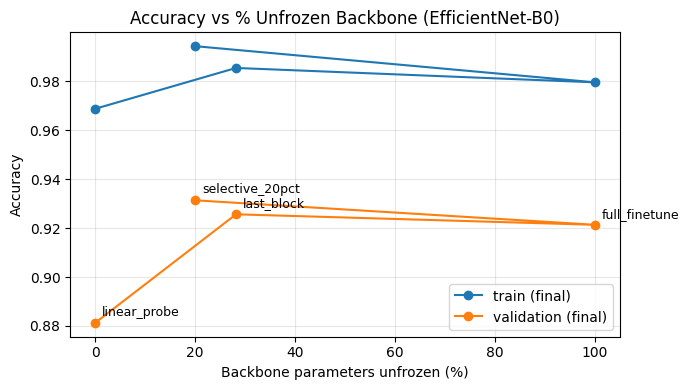


Gradient norm statistics across layers

linear_probe (backbone unfrozen=0.00%)
          stem | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
       mbconv1 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv2 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv3 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv4 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv5 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv6 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv7 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
          head | mean=6.1373e-01 | std=1.5348e-01 | max=9.2473e-01 | n=20

last_block (backbone unfrozen=28.18%)
          stem | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=20
       mbconv1 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
       mbconv2 | mean=0.0000e+00 | std=0.0000e+00 | max=0.0000e+00 | n=0
  

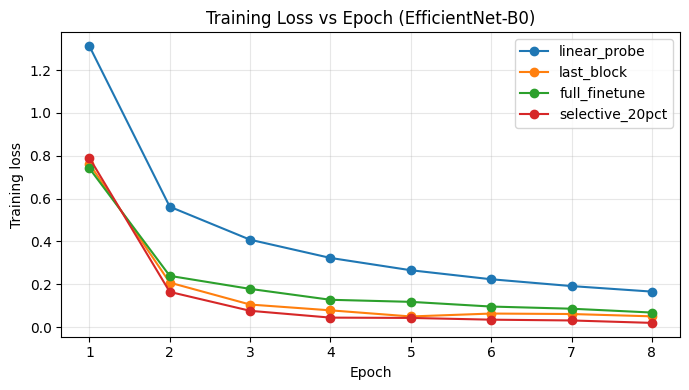

In [22]:
import matplotlib.pyplot as plt

# 1) Training and validation accuracy vs percentage of unfrozen parameters
xs = [h.percent_backbone_unfrozen for h in FT_HISTORIES]
final_train_acc = [h.train_acc[-1] for h in FT_HISTORIES]
final_val_acc = [h.val_acc[-1] for h in FT_HISTORIES]
labels = [h.strategy for h in FT_HISTORIES]
print("Training and validation accuracy vs percentage of unfrozen parameters")
for x, tr, va, lab in sorted(zip(xs, final_train_acc, final_val_acc, labels), key=lambda t: t[0]):
    print(f"{lab:>14} | backbone unfrozen={x:6.2f}% | train acc={tr:.4f} | val acc={va:.4f}")
plt.figure(figsize=(7, 4))
plt.plot(xs, final_train_acc, "o-", label="train (final)")
plt.plot(xs, final_val_acc, "o-", label="validation (final)")
for x, y, lab in zip(xs, final_val_acc, labels):
    plt.annotate(lab, (x, y), textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.xlabel("Backbone parameters unfrozen (%)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs % Unfrozen Backbone (EfficientNet-B0)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 2) Gradient norm statistics across layers
print("\nGradient norm statistics across layers")
# EfficientNet-B0: stem → 7 MBConv stages → head
layer_groups = ["stem", "mbconv1", "mbconv2", "mbconv3", "mbconv4", "mbconv5", "mbconv6", "mbconv7", "head"]
last_epoch_idx = EPOCHS - 1
for h in FT_HISTORIES:
    print(f"\n{h.strategy} (backbone unfrozen={h.percent_backbone_unfrozen:.2f}%)")
    stats = h.grad_norm_stats_by_epoch[last_epoch_idx]
    for g in layer_groups:
        s = stats.get(g, {"mean": 0.0, "std": 0.0, "max": 0.0, "n": 0})
        print(f"  {g:>12} | mean={s['mean']:.4e} | std={s['std']:.4e} | max={s['max']:.4e} | n={s['n']}")

# 3) Convergence stability comparison (training loss vs epoch)
print("\nConvergence stability comparison (training loss vs epoch)")
epochs = list(range(1, EPOCHS + 1))
plt.figure(figsize=(7, 4))
for h in FT_HISTORIES:
    plt.plot(epochs, h.train_loss, marker="o", label=h.strategy)
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Training Loss vs Epoch (EfficientNet-B0)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()